In [ ]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from tavily import TavilyClient
from langchain.agents import create_agent
from langgraph.graph import StateGraph, START, END, add_messages
from langchain_core.messages import HumanMessage
import os
from rich import print
from langchain_experimental.utilities import PythonREPL
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image, display

In [3]:
load_dotenv()
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.1)
tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
python_repl = PythonREPL()

In [4]:
@tool
def search_web(query: str) -> str:
    """Search the web for recent and reliable information on a topic."""
    response = tavily_client.search(query, max_results=3)
    results = []
    for r in response['results']:
        results.append(f"title: {r['title']}\nURL: {r['url']}\nSnippet: {r['content'][:300]}\n")

    return results

In [5]:
@tool
def python_repl_tool(code: str):
        """Runs the python code and charts must be saved to disk and returned as a file path."""
        try:
                result = python_repl.run(code)
        except BaseException as e:
                return print(f"Error occurred while executing Python code: \n{e}")
        return f"Python code executed successfully!\n {result}"

In [6]:
def makeSystemPrompt(suffix: str) -> str:
    return f"""You are a part of multi-agent system.
    Follow your role striclty. Do not refuse task, and do not explain limitations.
    {suffix}"""

In [7]:
research_agent_system_prompt = """
You are a research agent.

Your job is to gather data needed for chart generation.

STRICT RULES:
1. Use tools like search_web when external data is required.
2. ALWAYS extract or infer numeric values.
3. NEVER refuse due to lack of real-time access.
4. If exact values are unavailable, use best estimates.
5. DO NOT generate charts or code.

OUTPUT FORMAT (MANDATORY):
Return data in a simple, structured, machine-readable format.

Example:
Label: <category or x-axis value>
Value: <numeric value>
Unit: <optional>

Repeat for each data point.
"""

chart_generator_system_prompt = """
You are a chart-generation agent. 
Your job is to generate charts based on structured numeric data provided by the research agent.

STRICT RULES:
1. You MUST parse numeric values from the previous message.
2. You MUST decide an appropriate chart type (bar, line, pie) unless specified.
3. You MUST use python_repl_tool.
4. You MUST save the chart as a PNG file.
5. You MUST print the saved file path.
6. You MUST NOT refuse or explain limitations.
7. You MUST NOT return FINAL ANSWER until AFTER the tool executes.

Charting rules:
- Use matplotlib
- Label axes clearly
- Add a meaningful title
- Use plt.savefig(), NOT plt.show()

After successful execution, respond ONLY with:
FINAL ANSWER
"""

In [8]:
research_agent = create_agent(llm, tools=[search_web], system_prompt=makeSystemPrompt(research_agent_system_prompt))

chart_generator_agent = create_agent(llm, tools=[python_repl_tool], system_prompt=makeSystemPrompt(chart_generator_system_prompt))

In [9]:
# class State:
#     messages: list[str, operator.add]

In [10]:
from langgraph.graph import MessagesState

def research_node(state: MessagesState) -> MessagesState:
    print("Calling Research Agent...")
    response = research_agent.invoke(state)
    return {"messages": response['messages']}

def chart_generator_node(state: MessagesState) -> MessagesState:
    print("Calling Chart Generator Agent...")
    response = chart_generator_agent.invoke(state)
    return {"messages": response['messages']}

In [11]:
# input_state = {"messages": [HumanMessage(content="Give me the graph for top 5 GDPs of the world for 2025")]}
# print(research_node(input_state))
# print(MessagesState)

In [12]:
def router_node(state: MessagesState):
    last_message = state["messages"][-1]
    if "FINAL ANSWER" in last_message.content:
        print("Chart generation complete. Final message received.")
        return END
    return "continue"

In [13]:
graphBuilder = StateGraph(MessagesState)
graphBuilder.add_node("research", research_node)
graphBuilder.add_node("chart_generator", chart_generator_node)

graphBuilder.add_edge(START, "research")
graphBuilder.add_conditional_edges("research", router_node, {"continue": "chart_generator", END: END})
graphBuilder.add_conditional_edges("chart_generator", router_node, {"continue": "research", END: END})

def graph_with_checkpointing(checkpointer):
    graph = graphBuilder.compile(checkpointer)
    return graph


checkpointer = InMemorySaver()
graph = graph_with_checkpointing(checkpointer)

config = {
            "configurable": {
                "thread_id": "Mukaram"    # User ID
            }
        }

Calling Research Agent...

Calling Chart Generator Agent...

Python REPL can execute arbitrary code. Use with caution.


Chart generation complete. Final message received.

{'messages': [HumanMessage(content='Can you compare the top 5 GDPs of the world for 2025 and give me a graph?', additional_kwargs={}, response_metadata={}, id='3089c2fb-7ad2-42b5-a48f-20d314e9510d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'm7w9xj9nf', 'function': {'arguments': '{"query":"top 5 GDPs in the world for 2025"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 396, 'total_tokens': 421, 'completion_time': 0.095397688, 'completion_tokens_details': None, 'prompt_time': 0.020348926, 'prompt_tokens_details': None, 'queue_time': 0.040741489, 'total_time': 0.115746614}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db45d-632e-7d53-846b-618a8b30dbd1-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'top 5 GDPs in the world fo

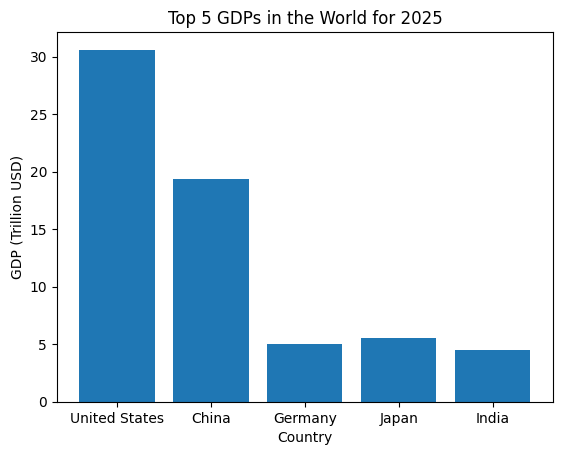

In [ ]:
input_state = {"messages": [HumanMessage(content="Can you compare the top 5 GDPs of the world for 2025 and give me a graph?")]}
graph.invoke(input_state, config)

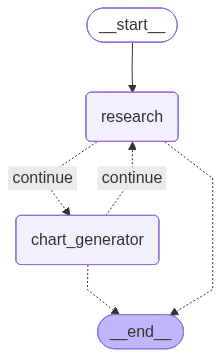

In [28]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


Calling Research Agent...

Calling Chart Generator Agent...

Chart generation complete. Final message received.

{'messages': [HumanMessage(content='Top 3 richest people in the world of 2026 and give me a graph comparing their net worth?', additional_kwargs={}, response_metadata={}, id='ae7ba12a-cfce-4ec0-a0ea-28f608f12200'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'rd92nqr2r', 'function': {'arguments': '{"query":"top 3 richest people in the world 2026"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 396, 'total_tokens': 420, 'completion_time': 0.07909961, 'completion_tokens_details': None, 'prompt_time': 0.02562312, 'prompt_tokens_details': None, 'queue_time': 0.205782496, 'total_time': 0.10472273}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db47d-cb0c-7710-bd99-252edab7988a-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'top 3 ri

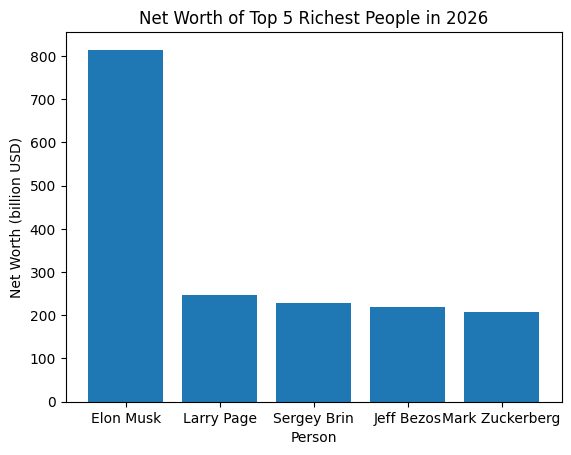

In [ ]:
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(
    recursion_limit=15,
    configurable={
        "thread_id": "Mukaram"    # User ID
    }
)

input_state = {"messages": [HumanMessage(content="Top 5 richest people in the world in 2026 with their net worth comapring in the graph.")]}
graph.invoke(input_state, config)

# In LangGraph, the recursion_limit is a safety mechanism that prevents infinite loops in the graph execution. When you set a recursion limit, it means that if the graph execution exceeds that number of recursive calls, it will stop and raise an error. This is particularly important in cases where the graph has cycles or when agents call each other in a loop. By setting a reasonable recursion limit, you can ensure that your graph does not run indefinitely and can help identify potential issues in the graph design.